# The Gut-Age Index (GAI) — Method Explainer

> **Reference**: Bao *et al.* (2024), "Gut microbiome-based supervised machine learning for clinical diagnosis of inflammatory bowel diseases", *Sci Rep* 14:31143.

This notebook provides a **visual walk-through** of the original GAI pipeline using pre-computed results from `my_output/`.  No models are retrained here — we focus purely on illustrating the logic, the mathematics, and the geometry of the method.

## 1  Pipeline Overview

The GAI method converts a high-dimensional OTU table into a **single scalar** per sample, then classifies health status from that scalar.  The pipeline has four stages:

| Stage | Input | Output |
|-------|-------|--------|
| **A. Age regression** | OTU vectors of *healthy* subjects | Regression model $f$ |
| **B. Raw GAI** | $f$ applied to *all* subjects | $\text{GAI}_{\text{raw}}$ per sample |
| **C. Bias correction** | Age-binned healthy $\text{GAI}_{\text{raw}}$ | $\text{GAI}_{\text{corr}}$ per sample |
| **D. Classification** | $\text{GAI}_{\text{corr}}$ | Healthy / Non-healthy label |

## 2  Mathematical Treatment

### Stage A — Age Regression on Healthy Subjects

Let $\mathbf{x}_i \in \mathbb{R}^p$ be the OTU feature vector for subject $i$ and $a_i$ be their chronological age.  We restrict to the **healthy subset** $\mathcal{H}$ and train a regression model:

$$f : \mathbb{R}^p \longrightarrow \mathbb{R}, \qquad f(\mathbf{x}_i) \approx a_i \quad \forall\, i \in \mathcal{H}$$

The output $\hat{a}_i = f(\mathbf{x}_i)$ is the **predicted gut age**: the age that the gut microbiome "looks like."

---

### Stage B — Raw GAI

Apply $f$ to **all** subjects (healthy and non-healthy).  The raw Gut-Age Index is the residual:

$$\text{GAI}_{\text{raw},i} \;=\; \hat{a}_i - a_i \;=\; f(\mathbf{x}_i) - a_i$$

- $\text{GAI}_{\text{raw}} > 0$: gut microbiome looks **older** than chronological age
- $\text{GAI}_{\text{raw}} < 0$: gut microbiome looks **younger** than chronological age

**Problem:** Age regression is biased — $f$ systematically over-predicts for young subjects and under-predicts for old subjects (regression to the mean).  This makes $\text{GAI}_{\text{raw}}$ depend on age even for healthy people.

---

### Stage C — Bias Correction

Partition the age axis into $K$ bins $B_1, \ldots, B_K$ (e.g. $[18,20), [20,25), \ldots, [75,100)$).

For each bin $B_k$, compute the **healthy-mean residual**:

$$\mu_k \;=\; \frac{1}{|\mathcal{H} \cap B_k|} \sum_{i \in \mathcal{H} \cap B_k} \text{GAI}_{\text{raw},i}$$

Then for every subject $i$ in bin $B_k$:

$$\text{GAI}_{\text{corr},i} \;=\; \text{GAI}_{\text{raw},i} \;-\; \mu_k$$

After correction, healthy subjects in each bin have zero-mean GAI by construction.

---

### Stage D — Classification

Fit a **logistic regression** on the corrected GAI:

$$P(\text{non-healthy} \mid \text{GAI}_{\text{corr}}) \;=\; \sigma\!\bigl(\beta_0 + \beta_1 \cdot \text{GAI}_{\text{corr}}\bigr)$$

where $\sigma(z) = 1/(1 + e^{-z})$.  A threshold $\tau$ on the predicted probability yields the final binary label.

## 3  Load Pre-Computed Results

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.stats import gaussian_kde

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

DATASETS = {
    "AGP":  "my_output/AGP-agefix",
    "GGMP": "my_output/GGMP-agefix",
}

results = {}
adjustments = {}

for label, path in DATASETS.items():
    df = pd.read_csv(f"{path}/result.tsv", sep="\t")
    df["predicted_age"] = df["age"] + df["raw GAI"]
    df["is_healthy"] = df["health"] == "y"
    results[label] = df

    av = pd.read_csv(f"{path}/adjust_values.tsv", sep="\t")
    # parse string tuple "(lo, hi)" into numeric columns
    bounds = av["age_range"].apply(ast.literal_eval)
    av["lo"] = bounds.apply(lambda t: t[0])
    av["hi"] = bounds.apply(lambda t: t[1])
    adjustments[label] = av

print("Loaded datasets:", {k: v.shape for k, v in results.items()})

Loaded datasets: {'AGP': (5965, 8), 'GGMP': (6242, 8)}


## 4  Panel A — Predicted Gut Age vs Chronological Age

The regression model $f$ maps OTU vectors to a predicted "gut age" $\hat{a}$.  If the model were perfect, all points would lie on the identity line $\hat{a} = a$.  In practice, the cloud scatters around the diagonal with **regression to the mean**: young subjects are over-predicted and old subjects are under-predicted.

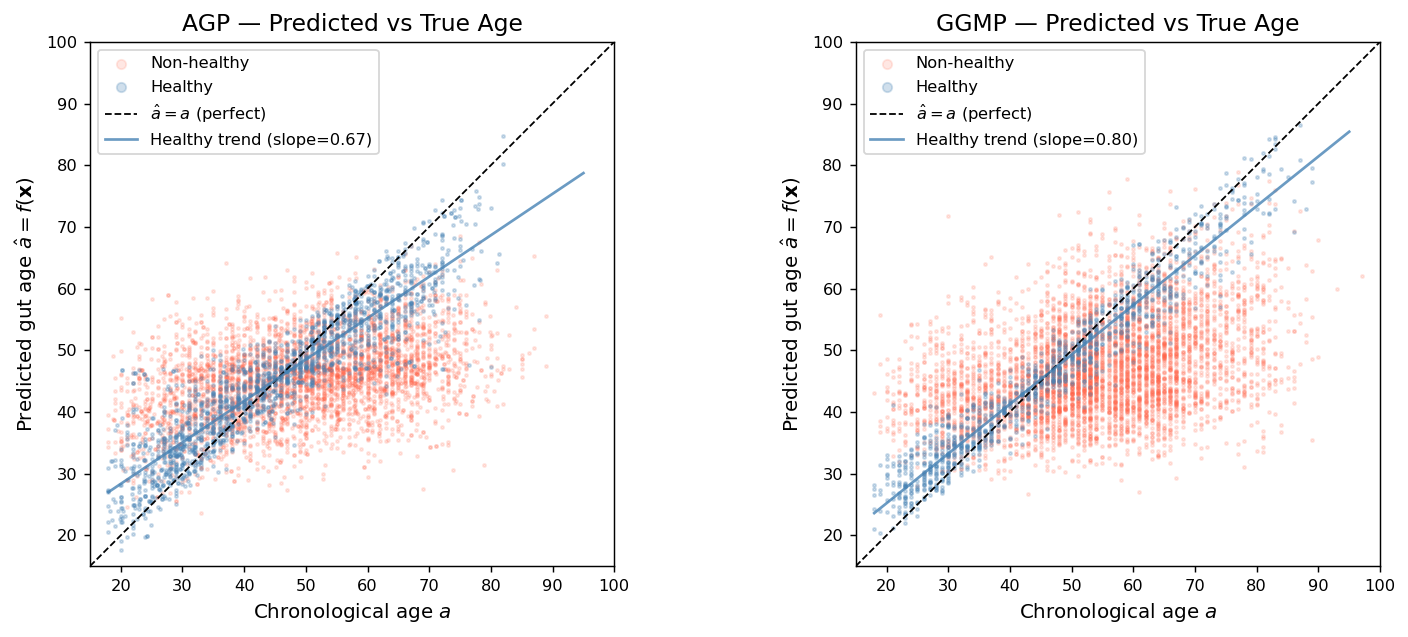

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, df) in zip(axes, results.items()):
    h = df[df.is_healthy]
    n = df[~df.is_healthy]

    ax.scatter(n["age"], n["predicted_age"], s=3, alpha=0.15, c="tomato",    label="Non-healthy", rasterized=True)
    ax.scatter(h["age"], h["predicted_age"], s=3, alpha=0.25, c="steelblue", label="Healthy",     rasterized=True)

    lims = [15, 100]
    ax.plot(lims, lims, "k--", lw=1, label="$\\hat{a} = a$ (perfect)")

    # trend line (healthy only)
    z = np.polyfit(h["age"], h["predicted_age"], 1)
    xs = np.linspace(18, 95, 100)
    ax.plot(xs, np.polyval(z, xs), "-", color="steelblue", lw=1.5, alpha=0.8,
            label=f"Healthy trend (slope={z[0]:.2f})")

    ax.set_xlim(15, 100)
    ax.set_ylim(15, 100)
    ax.set_xlabel("Chronological age $a$")
    ax.set_ylabel("Predicted gut age $\\hat{a} = f(\\mathbf{x})$")
    ax.set_title(f"{label} — Predicted vs True Age")
    ax.legend(loc="upper left", markerscale=3)
    ax.set_aspect("equal")

fig.tight_layout()
plt.show()

## 5  Panel B — Raw GAI and the Bias Problem

Now we rotate our view.  The horizontal axis becomes $\text{GAI}_{\text{raw}} = \hat{a} - a$ and the vertical axis remains chronological age $a$.  The GAI is essentially a **1-dimensional embedding** of the gut microbiome relative to age.

For a perfect, unbiased model, the healthy cloud would be centred at $\text{GAI} = 0$ at every age.  Instead, the **healthy mean drifts** — positive for young subjects, negative for old — tracing out a bias curve.

We overlay the **age-bin boundaries** and the **adjustment arrows** $\mu_k$ that the method uses to push the healthy mean back to zero.

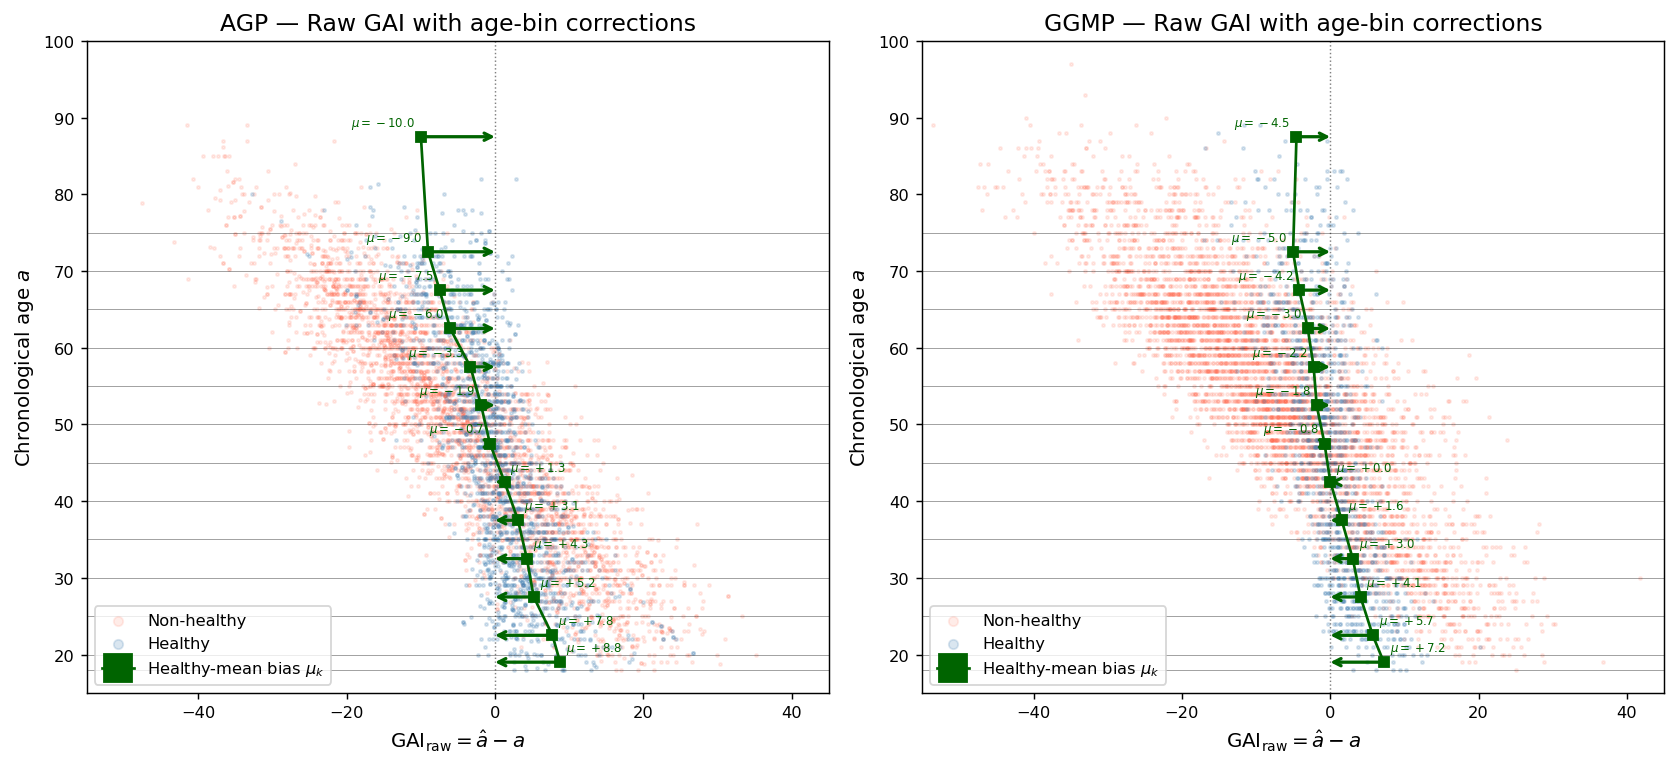

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (label, df) in zip(axes, results.items()):
    av = adjustments[label]
    h = df[df.is_healthy]
    n = df[~df.is_healthy]

    # --- scatter ---
    ax.scatter(n["raw GAI"], n["age"], s=3, alpha=0.12, c="tomato",    label="Non-healthy", rasterized=True)
    ax.scatter(h["raw GAI"], h["age"], s=3, alpha=0.20, c="steelblue", label="Healthy",     rasterized=True)

    # --- zero line ---
    ax.axvline(0, color="grey", ls=":", lw=0.8)

    # --- age-bin boundaries (horizontal bands) ---
    for _, row in av.iterrows():
        lo, hi = row["lo"], row["hi"]
        ax.axhline(lo, color="black", ls="-", lw=0.4, alpha=0.5)

        # arrow from healthy mean (µ_k) to zero at the bin midpoint
        mid = (lo + hi) / 2
        mu = row["adjust_value"]
        ax.annotate(
            "", xy=(0, mid), xytext=(mu, mid),
            arrowprops=dict(arrowstyle="->", color="darkgreen", lw=1.8, shrinkA=0, shrinkB=0),
        )
        # label the adjustment value
        ax.text(mu + (0.8 if mu >= 0 else -0.8), mid + 0.8,
                f"$\\mu={mu:+.1f}$", fontsize=6.5, color="darkgreen",
                ha="left" if mu >= 0 else "right", va="bottom")

    # draw top boundary
    ax.axhline(av["hi"].max(), color="black", ls="-", lw=0.4, alpha=0.5)

    # --- healthy mean curve ---
    bin_mids = (av["lo"] + av["hi"]) / 2
    ax.plot(av["adjust_value"], bin_mids, "s-", color="darkgreen", ms=5, lw=1.5,
            label="Healthy-mean bias $\\mu_k$", zorder=5)

    ax.set_xlabel("$\\mathrm{GAI}_{\\mathrm{raw}} = \\hat{a} - a$")
    ax.set_ylabel("Chronological age $a$")
    ax.set_title(f"{label} — Raw GAI with age-bin corrections")
    ax.legend(loc="lower left", markerscale=3)
    ax.set_xlim(-55, 45)
    ax.set_ylim(15, 100)

fig.tight_layout()
plt.show()

## 6  Panel C — Corrected GAI

After subtracting the per-bin healthy mean $\mu_k$, the **corrected GAI** centres the healthy cloud at zero regardless of age.

$$\text{GAI}_{\text{corr},i} = \text{GAI}_{\text{raw},i} - \mu_{k(i)}$$

The scatter below shows the same subjects with the bias removed.  The healthy cloud should now be roughly symmetric around $\text{GAI}_{\text{corr}} = 0$ at every age.

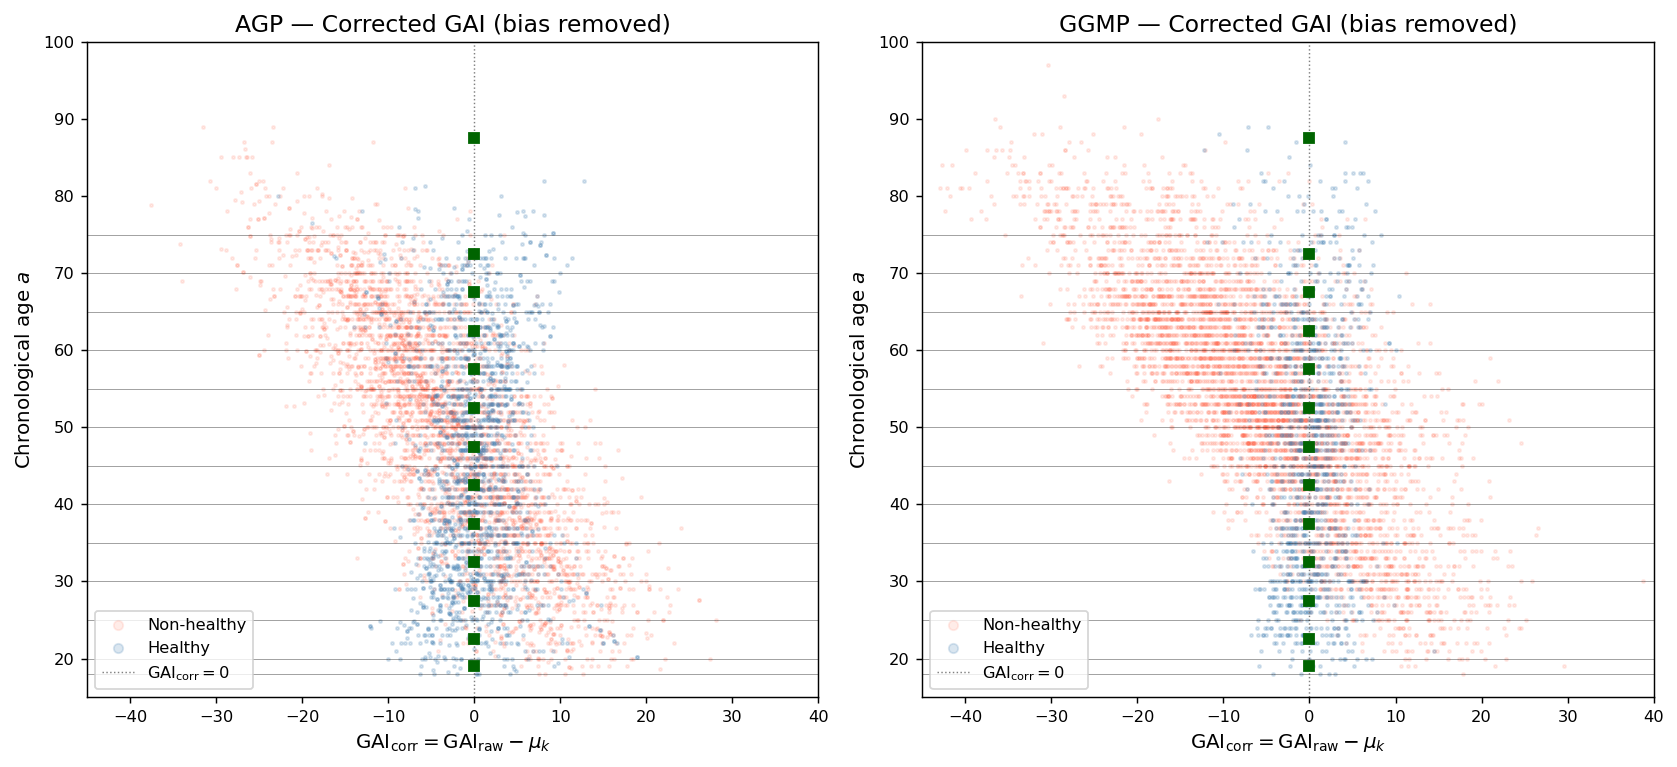

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (label, df) in zip(axes, results.items()):
    av = adjustments[label]
    h = df[df.is_healthy]
    n = df[~df.is_healthy]

    ax.scatter(n["corrected GAI"], n["age"], s=3, alpha=0.12, c="tomato",    label="Non-healthy", rasterized=True)
    ax.scatter(h["corrected GAI"], h["age"], s=3, alpha=0.20, c="steelblue", label="Healthy",     rasterized=True)
    ax.axvline(0, color="grey", ls=":", lw=0.8, label="$\\mathrm{GAI}_{\\mathrm{corr}} = 0$")

    # bin boundaries
    for _, row in av.iterrows():
        ax.axhline(row["lo"], color="black", ls="-", lw=0.4, alpha=0.5)
    ax.axhline(av["hi"].max(), color="black", ls="-", lw=0.4, alpha=0.5)

    # healthy mean per bin (should now be ≈ 0)
    for _, row in av.iterrows():
        lo, hi = row["lo"], row["hi"]
        mid = (lo + hi) / 2
        mask = h["age"].between(lo, hi, inclusive="left")
        if mask.sum() > 0:
            mu_corr = h.loc[mask, "corrected GAI"].mean()
            ax.plot(mu_corr, mid, "s", color="darkgreen", ms=5, zorder=5)

    ax.set_xlabel("$\\mathrm{GAI}_{\\mathrm{corr}} = \\mathrm{GAI}_{\\mathrm{raw}} - \\mu_k$")
    ax.set_ylabel("Chronological age $a$")
    ax.set_title(f"{label} — Corrected GAI (bias removed)")
    ax.legend(loc="lower left", markerscale=3)
    ax.set_xlim(-45, 40)
    ax.set_ylim(15, 100)

fig.tight_layout()
plt.show()

## 7  Panel D — Distribution Thresholds

The corrected GAI has collapsed the problem to a **1-D classification task**.  Below we show kernel-density estimates (KDE) of $\text{GAI}_{\text{corr}}$ for healthy vs non-healthy subjects.

The paper then fits a logistic regression on this single feature:

$$P(\text{non-healthy}) = \sigma(\beta_0 + \beta_1 \cdot \text{GAI}_{\text{corr}})$$

We overlay the logistic decision boundary (the threshold where $P = 0.5$) to show how the two distributions are separated.

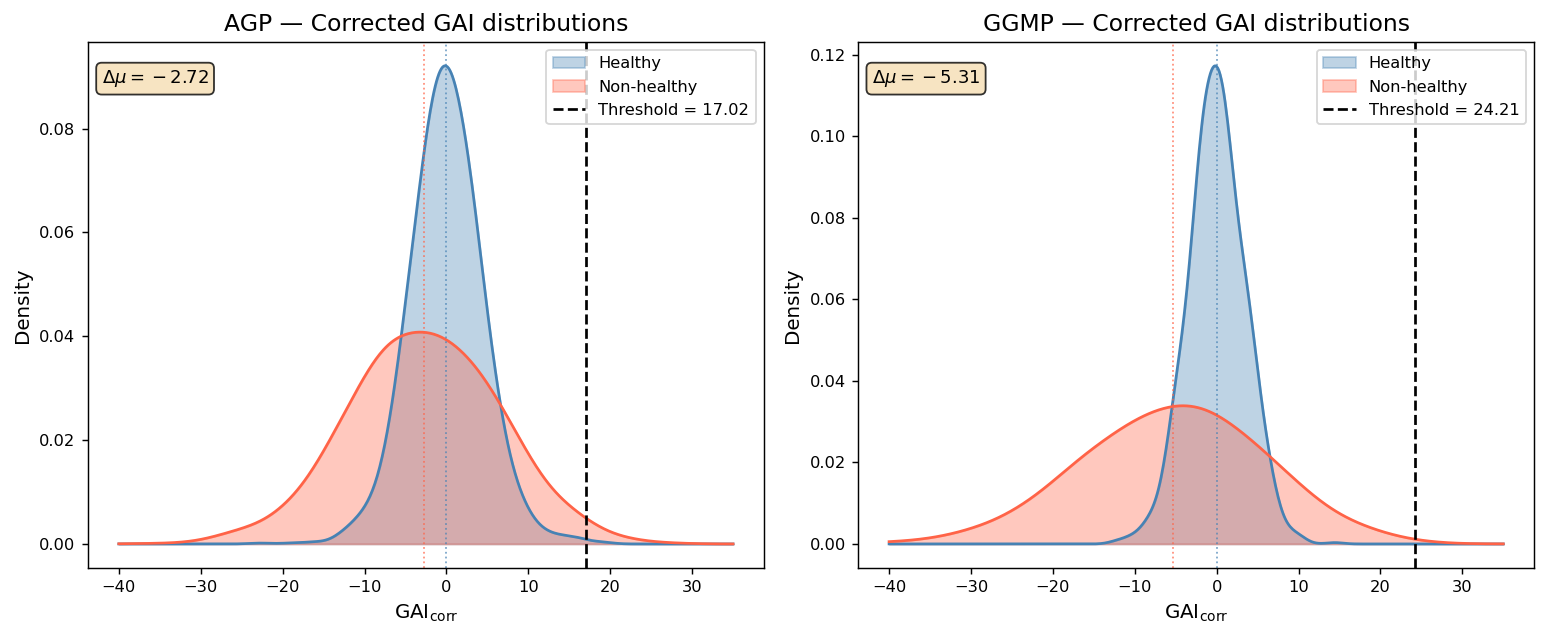

In [5]:
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, df) in zip(axes, results.items()):
    h_gai = df.loc[df.is_healthy,  "corrected GAI"].values
    n_gai = df.loc[~df.is_healthy, "corrected GAI"].values

    # KDE
    grid = np.linspace(-40, 35, 500)
    kde_h = gaussian_kde(h_gai, bw_method=0.3)
    kde_n = gaussian_kde(n_gai, bw_method=0.3)

    ax.fill_between(grid, kde_h(grid), alpha=0.35, color="steelblue", label="Healthy")
    ax.fill_between(grid, kde_n(grid), alpha=0.35, color="tomato",    label="Non-healthy")
    ax.plot(grid, kde_h(grid), color="steelblue", lw=1.5)
    ax.plot(grid, kde_n(grid), color="tomato",    lw=1.5)

    # Fit logistic regression to find threshold
    X = df["corrected GAI"].values.reshape(-1, 1)
    y = (~df.is_healthy).astype(int).values
    lr = LogisticRegression(solver="lbfgs", max_iter=1000).fit(X, y)
    # decision boundary: β₀ + β₁·x = 0  →  x = -β₀/β₁
    threshold = -lr.intercept_[0] / lr.coef_[0, 0]

    ax.axvline(threshold, color="black", ls="--", lw=1.5,
               label=f"Threshold = {threshold:.2f}")

    # show the means
    ax.axvline(h_gai.mean(), color="steelblue", ls=":", lw=1, alpha=0.7)
    ax.axvline(n_gai.mean(), color="tomato",    ls=":", lw=1, alpha=0.7)

    ax.set_xlabel("$\\mathrm{GAI}_{\\mathrm{corr}}$")
    ax.set_ylabel("Density")
    ax.set_title(f"{label} — Corrected GAI distributions")
    ax.legend(loc="upper right")

    # annotate
    sep = n_gai.mean() - h_gai.mean()
    ax.text(0.02, 0.95, f"$\\Delta\\mu = {sep:.2f}$", transform=ax.transAxes,
            fontsize=10, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.8))

fig.tight_layout()
plt.show()

## 8  Combined View — Before and After Correction

The figure below puts the raw and corrected GAI side by side for one dataset to make the **effect of bias correction** immediately visible.

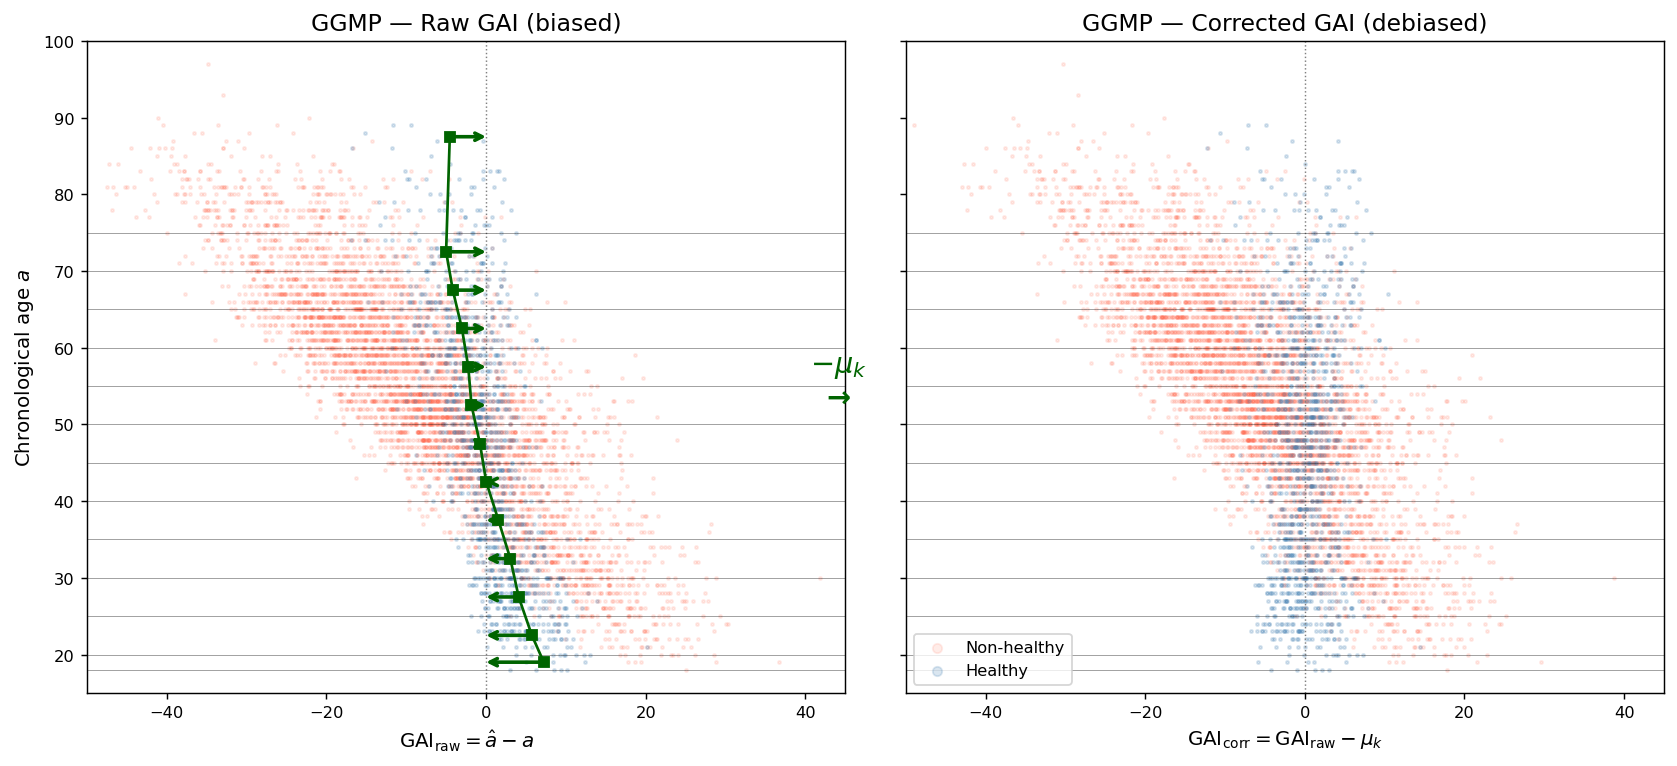

In [6]:
# Side-by-side: raw vs corrected GAI for GGMP
label = "GGMP"
df = results[label]
av = adjustments[label]
h = df[df.is_healthy]
n = df[~df.is_healthy]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

# ---- Left: Raw GAI ----
ax1.scatter(n["raw GAI"], n["age"], s=3, alpha=0.12, c="tomato",    rasterized=True)
ax1.scatter(h["raw GAI"], h["age"], s=3, alpha=0.20, c="steelblue", rasterized=True)
ax1.axvline(0, color="grey", ls=":", lw=0.8)

# age-bin boundaries + arrows
for _, row in av.iterrows():
    lo, hi = row["lo"], row["hi"]
    mid = (lo + hi) / 2
    mu = row["adjust_value"]
    ax1.axhline(lo, color="black", ls="-", lw=0.4, alpha=0.5)
    ax1.annotate("", xy=(0, mid), xytext=(mu, mid),
                 arrowprops=dict(arrowstyle="->", color="darkgreen", lw=2, shrinkA=0, shrinkB=0))
ax1.axhline(av["hi"].max(), color="black", ls="-", lw=0.4, alpha=0.5)

# bias curve
bin_mids = (av["lo"] + av["hi"]) / 2
ax1.plot(av["adjust_value"], bin_mids, "s-", color="darkgreen", ms=5, lw=1.5, zorder=5)

ax1.set_xlabel("$\\mathrm{GAI}_{\\mathrm{raw}} = \\hat{a} - a$")
ax1.set_ylabel("Chronological age $a$")
ax1.set_title(f"{label} — Raw GAI (biased)")
ax1.set_xlim(-50, 45)
ax1.set_ylim(15, 100)

# ---- Right: Corrected GAI ----
ax2.scatter(n["corrected GAI"], n["age"], s=3, alpha=0.12, c="tomato",    rasterized=True, label="Non-healthy")
ax2.scatter(h["corrected GAI"], h["age"], s=3, alpha=0.20, c="steelblue", rasterized=True, label="Healthy")
ax2.axvline(0, color="grey", ls=":", lw=0.8)

for _, row in av.iterrows():
    ax2.axhline(row["lo"], color="black", ls="-", lw=0.4, alpha=0.5)
ax2.axhline(av["hi"].max(), color="black", ls="-", lw=0.4, alpha=0.5)

ax2.set_xlabel("$\\mathrm{GAI}_{\\mathrm{corr}} = \\mathrm{GAI}_{\\mathrm{raw}} - \\mu_k$")
ax2.set_title(f"{label} — Corrected GAI (debiased)")
ax2.set_xlim(-50, 45)
ax2.legend(loc="lower left", markerscale=3)

# arrows between panels
fig.text(0.50, 0.50, "$ - \\mu_k$\n→", fontsize=16, ha="center", va="center",
         fontweight="bold", color="darkgreen")

fig.tight_layout(w_pad=3)
plt.show()

## 9  Summary

| Step | What happens | Visualised in |
|------|-------------|---------------|
| **Regression** | Train $f$ on healthy OTU → age | Panel A |
| **Raw GAI** | $\hat{a} - a$ reveals age-dependent bias | Panel B |
| **Correction** | Subtract $\mu_k$ per age bin → zero mean for healthy | Panel C (+ Combined) |
| **Classification** | Logistic regression on 1-D corrected GAI | Panel D |

### Key Insight

The entire pipeline compresses a high-dimensional microbiome profile into a **single number** — the corrected GAI — then bets that this number alone is enough to separate healthy from non-healthy subjects.  The bias-correction step is essential: without it, young healthy subjects would look non-healthy (positive GAI) and old healthy subjects would look healthy (negative GAI), purely due to regression-to-the-mean artefacts.

### Caveat

In the original paper, the regression model is trained on **all** healthy subjects and then the raw GAI is computed on the **same** healthy subjects.  The adjustment values $\mu_k$ are therefore in-sample statistics.  This means the bias correction is overly optimistic — it sees test data during training — which inflates downstream classification metrics.  See `gai-baseline.ipynb` for a nested cross-validation approach that avoids this leakage.